# Customer Segmentation -- RFM + Behavioral Clustering

ShipSmart already assigns a commercial tier to every account (Enterprise /
Mid-Market / SMB / Occasional), set by sales ops at signup. This notebook
asks a different question: **does a data-driven, behavior-based
segmentation agree with that tier -- and where does it disagree in a way
that's commercially useful?**

We build RFM-style features (recency, frequency, monetary value) plus a
few pricing-behavior features, cluster with K-Means, and profile the
result. Because we have the assigned tier as a label, we can also
quantify how well the two agree (they should mostly agree, since tier
drives behavior in the simulation -- but a few accounts will look
"misfiled", which is exactly the kind of finding worth flagging to
Sales/Pricing in a real engagement).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
import sys, os

sys.path.append(os.getcwd())
from config import DATA_DIR, FIG_DIR, CATEGORICAL, SEQUENTIAL_BLUE, INK, SEGMENT_ORDER, RANDOM_SEED, set_style

set_style()
FIG_SUBDIR = os.path.join(FIG_DIR, "02_segmentation")
os.makedirs(FIG_SUBDIR, exist_ok=True)

customers = pd.read_csv(os.path.join(DATA_DIR, "customers.csv"), parse_dates=["signup_date"])
quotes = pd.read_csv(os.path.join(DATA_DIR, "quotes.csv"), parse_dates=["quote_date"])
TODAY = pd.Timestamp("2026-08-20")

print(f"customers: {customers.shape}, quotes: {quotes.shape}")

customers: (3000, 7), quotes: (92530, 13)

## 1. Build RFM + behavioral features

- **Recency**: days since last quote
- **Frequency**: total number of quotes
- **Monetary**: total revenue from accepted quotes
- **Acceptance rate**: share of quotes accepted (a proxy for how well we
  price this account today)
- **Avg price ratio**: our price vs. the competitor's, on average
- **Express share**: share of shipments booked as Express (urgency /
  service-value signal)
- **Avg shipment size**: average weight, as a scale proxy

In [2]:
acc = quotes[quotes["accepted"] == 1]
last_quote = quotes.groupby("customer_id")["quote_date"].max()

rfm = quotes.groupby("customer_id").agg(
    frequency=("quote_id", "count"),
    acceptance_rate=("accepted", "mean"),
    avg_price_ratio=("price_ratio", "mean"),
    express_share=("service_level", lambda s: (s == "Express").mean()),
    avg_weight_kg=("weight_kg", "mean"),
    avg_distance_km=("distance_km", "mean"),
)
rfm["recency_days"] = (TODAY - last_quote).dt.days
rfm["monetary"] = acc.groupby("customer_id")["quoted_price"].sum()
rfm["monetary"] = rfm["monetary"].fillna(0)

features = customers.set_index("customer_id").join(rfm).dropna(subset=["frequency"])

# Raw frequency/monetary totals are confounded with tenure -- a
# long-tenured SMB account can rack up more *total* quotes than a
# recently-signed Enterprise account even though its per-year rate is
# much lower. We normalize to a per-active-year rate first, since that's
# the quantity that actually reflects segment behavior, then log-transform
# (still right-skewed) before scaling. Shipment size (weight/distance)
# turned out not to vary by tier in this business (freight mix is similar
# across segments), so we keep those for profiling only.
tenure_years = ((TODAY - features["signup_date"]).dt.days / 365.25).clip(lower=0.08)
features["tenure_years"] = tenure_years
features["frequency_per_year"] = features["frequency"] / tenure_years
features["monetary_per_year"] = features["monetary"] / tenure_years

features["log_frequency"] = np.log1p(features["frequency_per_year"])
features["log_monetary"] = np.log1p(features["monetary_per_year"])
features["log_recency"] = np.log1p(features["recency_days"])

feature_cols = ["log_recency", "log_frequency", "log_monetary",
                 "acceptance_rate", "avg_price_ratio", "express_share"]
profile_extra_cols = ["avg_weight_kg", "avg_distance_km", "tenure_years"]
print(f"Customers with usable behavior: {len(features):,}")
features[["recency_days", "frequency_per_year", "monetary_per_year"] + feature_cols[3:]].describe().T[["mean", "std", "min", "max"]]

Customers with usable behavior: 3,000

,mean,std,min,max
recency_days,75.792333,109.741060,1.000000,1545.000000
frequency_per_year,7.094274,4.167035,0.307191,23.313830
monetary_per_year,1295.017967,871.820623,0.000000,4863.445687
acceptance_rate,0.913419,0.080126,0.000000,1.000000
avg_price_ratio,0.980365,0.028606,0.806100,1.099400
express_share,0.238404,0.118155,0.000000,1.000000


## 2. Choose k -- elbow + silhouette

We scale features (K-Means is distance-based) and try k = 2..8, looking
at both inertia (elbow) and silhouette score.

Selected k = 4 (matches business tier count; silhouette = 0.188)

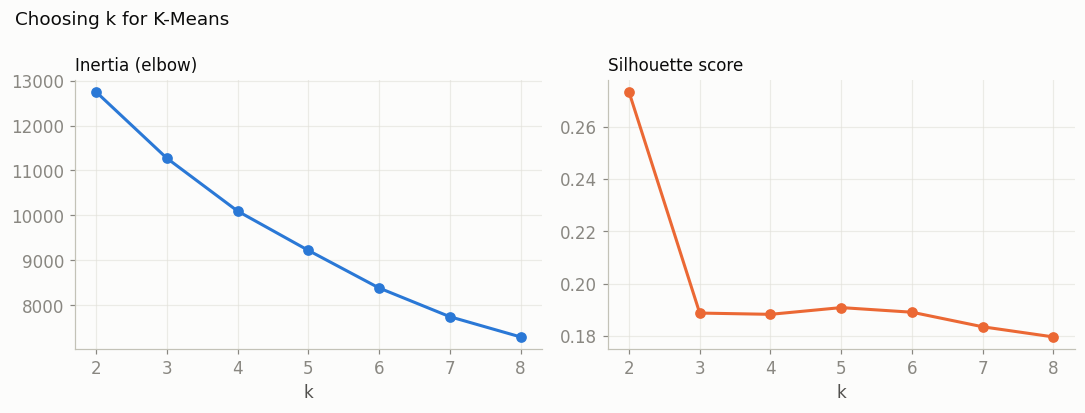

In [3]:
X = StandardScaler().fit_transform(features[feature_cols].values)

ks = range(2, 9)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(list(ks), inertias, marker="o", color=CATEGORICAL[0], linewidth=2)
axes[0].set_title("Inertia (elbow)", color=INK["primary"], fontsize=11, loc="left")
axes[0].set_xlabel("k")
axes[1].plot(list(ks), sils, marker="o", color=CATEGORICAL[1], linewidth=2)
axes[1].set_title("Silhouette score", color=INK["primary"], fontsize=11, loc="left")
axes[1].set_xlabel("k")
for ax in axes:
    ax.grid(True, alpha=0.6)
fig.suptitle("Choosing k for K-Means", fontsize=12, color=INK["primary"], x=0.02, ha="left")
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "01_elbow_silhouette.png"), bbox_inches="tight")
plt.show()

best_k = 4
print(f"Selected k = {best_k} (matches business tier count; silhouette = {sils[best_k-2]:.3f})")

## 3. Fit K-Means at k=4 and compare to the assigned tier

In [4]:
km = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10).fit(X)
features["cluster"] = km.labels_

ari = adjusted_rand_score(features["true_segment"], features["cluster"])
print(f"Adjusted Rand Index vs. assigned tier: {ari:.3f}  (1.0 = perfect agreement)")

crosstab = pd.crosstab(features["cluster"], features["true_segment"])[SEGMENT_ORDER]
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0)
crosstab

Adjusted Rand Index vs. assigned tier: 0.436  (1.0 = perfect agreement)

true_segment,Enterprise,Mid-Market,SMB,Occasional
cluster,,,,
0,0,0,93,329
1,227,808,51,0
2,0,6,125,153
3,0,246,924,38


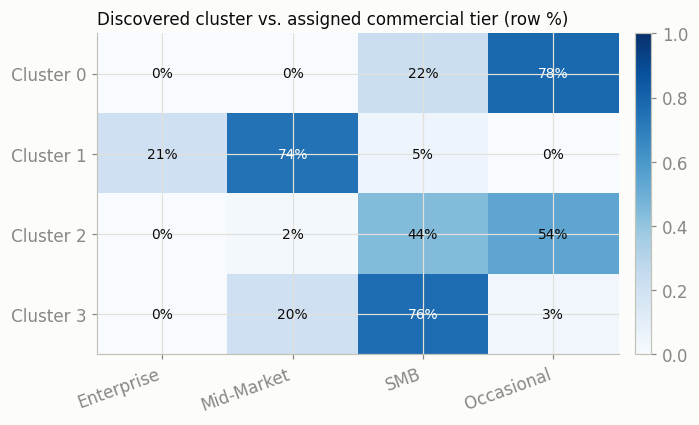

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4))
im = ax.imshow(crosstab_pct.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(SEGMENT_ORDER)))
ax.set_xticklabels(SEGMENT_ORDER, rotation=20, ha="right")
ax.set_yticks(range(best_k))
ax.set_yticklabels([f"Cluster {i}" for i in range(best_k)])
for i in range(crosstab_pct.shape[0]):
    for j in range(crosstab_pct.shape[1]):
        val = crosstab_pct.values[i, j]
        ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                color=INK["primary"] if val < 0.6 else "white", fontsize=9)
ax.set_title("Discovered cluster vs. assigned commercial tier (row %)", loc="left", fontsize=11)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "02_cluster_vs_tier.png"), bbox_inches="tight")
plt.show()

## 4. Profile each cluster and name it

In [6]:
raw_profile_cols = ["recency_days", "frequency_per_year", "monetary_per_year", "acceptance_rate",
                     "avg_price_ratio", "express_share"] + profile_extra_cols
profile = features.groupby("cluster")[raw_profile_cols].mean().round(2)
profile["n_customers"] = features.groupby("cluster").size()
profile["dominant_tier"] = crosstab.idxmax(axis=1)
profile_sorted = profile.sort_values("monetary_per_year", ascending=False)
profile_sorted

,recency_days,frequency_per_year,monetary_per_year,acceptance_rate,avg_price_ratio,express_share,avg_weight_kg,avg_distance_km,tenure_years,n_customers,dominant_tier
cluster,,,,,,,,,,,
1,26.38,11.42,2171.53,0.93,1.00,0.25,66.99,822.82,4.39,1086,Mid-Market
3,63.06,5.86,1029.91,0.92,0.97,0.23,66.44,812.96,4.47,1208,SMB
2,143.44,3.16,447.00,0.74,0.97,0.24,66.66,795.20,3.96,284,Occasional
0,193.87,2.14,368.94,0.96,0.95,0.24,69.76,817.15,4.18,422,Occasional


{1: 'High-Value Core', 0: 'Low-Engagement / Occasional', np.int32(2): 'Price-Sensitive / At-Risk', 3: 'Steady Mid-Value'}

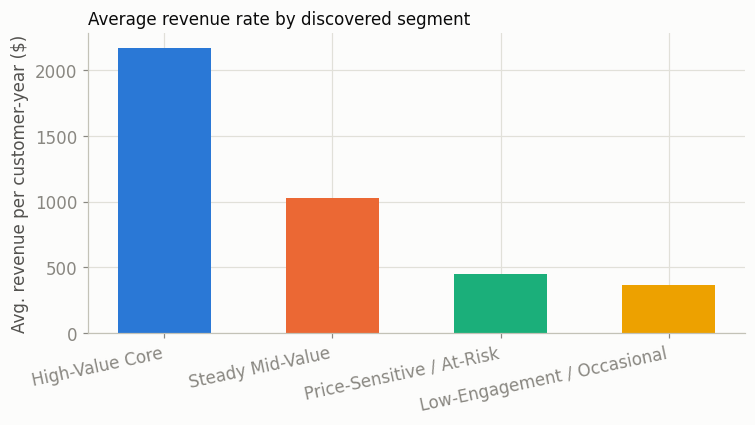

In [7]:
# Name clusters by rank rather than by ties on the raw mean, so every
# cluster gets a distinct, business-readable label: the top spender is
# "High-Value Core", the lowest-engagement cluster is "Low-Engagement /
# Occasional", and among whatever's left, the one with the weakest
# acceptance rate is flagged "Price-Sensitive / At-Risk".
by_monetary = profile["monetary_per_year"].sort_values(ascending=False).index.tolist()
top, bottom = by_monetary[0], by_monetary[-1]
remaining = [c for c in by_monetary if c not in (top, bottom)]
labels_map = {top: "High-Value Core", bottom: "Low-Engagement / Occasional"}
if remaining:
    weakest = profile.loc[remaining, "acceptance_rate"].idxmin()
    labels_map[weakest] = "Price-Sensitive / At-Risk"
    for c in remaining:
        if c not in labels_map:
            labels_map[c] = "Steady Mid-Value"
features["cluster_name"] = features["cluster"].map(labels_map)
print(labels_map)

fig, ax = plt.subplots(figsize=(7, 4))
order = profile_sorted.index.tolist()
bar_colors = [CATEGORICAL[i % len(CATEGORICAL)] for i in range(len(order))]
ax.bar([labels_map[c] for c in order], profile_sorted["monetary_per_year"], color=bar_colors, width=0.55)
ax.set_ylabel("Avg. revenue per customer-year ($)")
ax.set_title("Average revenue rate by discovered segment", loc="left", fontsize=11)
plt.xticks(rotation=12, ha="right")
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "03_cluster_revenue.png"), bbox_inches="tight")
plt.show()

## 5. Visualize in 2D (PCA)

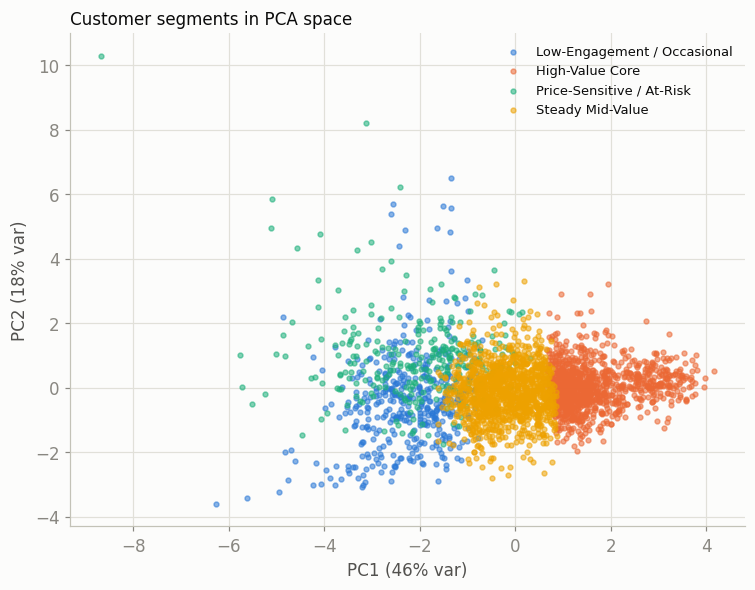

In [8]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(X)
fig, ax = plt.subplots(figsize=(7, 5.5))
for i, c in enumerate(sorted(features["cluster"].unique())):
    mask = features["cluster"].values == c
    ax.scatter(coords[mask, 0], coords[mask, 1], s=10, alpha=0.55,
               color=CATEGORICAL[i % len(CATEGORICAL)], label=f"{labels_map[c]}")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
ax.set_title("Customer segments in PCA space", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="best")
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "04_pca_scatter.png"), bbox_inches="tight")
plt.show()

## 6. Flag "misfiled" accounts

Accounts whose discovered cluster's dominant tier disagrees with their
assigned tier are worth a manual look -- e.g. an SMB-tier account
behaving like the High-Value Core cluster is a candidate for a tier
upgrade / dedicated account management.

In [9]:
features["dominant_tier_of_cluster"] = features["cluster"].map(crosstab.idxmax(axis=1))
mismatch = features[features["true_segment"] != features["dominant_tier_of_cluster"]]
print(f"{len(mismatch):,} of {len(features):,} accounts ({len(mismatch)/len(features):.1%}) sit in a cluster "
      f"dominated by a different tier than they're assigned.")
mismatch_summary = (
    mismatch.groupby(["true_segment", "cluster_name"]).size()
    .reset_index(name="n_accounts").sort_values("n_accounts", ascending=False)
)
mismatch_summary.head(10)

786 of 3,000 accounts (26.2%) sit in a cluster dominated by a different tier than they're assigned.

,true_segment,cluster_name,n_accounts
2,Mid-Market,Steady Mid-Value,246
0,Enterprise,High-Value Core,227
6,SMB,Price-Sensitive / At-Risk,125
5,SMB,Low-Engagement / Occasional,93
4,SMB,High-Value Core,51
3,Occasional,Steady Mid-Value,38
1,Mid-Market,Price-Sensitive / At-Risk,6


## 7. Save

In [10]:
out = features.reset_index()[[
    "customer_id", "true_segment", "cluster", "cluster_name", "dominant_tier_of_cluster",
    "recency_days", "frequency", "monetary", "acceptance_rate", "avg_price_ratio",
]]
out.to_csv(os.path.join(DATA_DIR, "customer_segments.csv"), index=False)
print("Saved data/customer_segments.csv:", out.shape)

Saved data/customer_segments.csv: (3000, 10)